# D5: Downstream Algorithm Impact (QAOA)

Evaluates the effect of the calibration policy on a $p=1$ QAOA for MaxCut on a 4-qubit ring.


In [1]:
import sys
sys.path.append('../q-autopilot-backend/src')
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(2026)


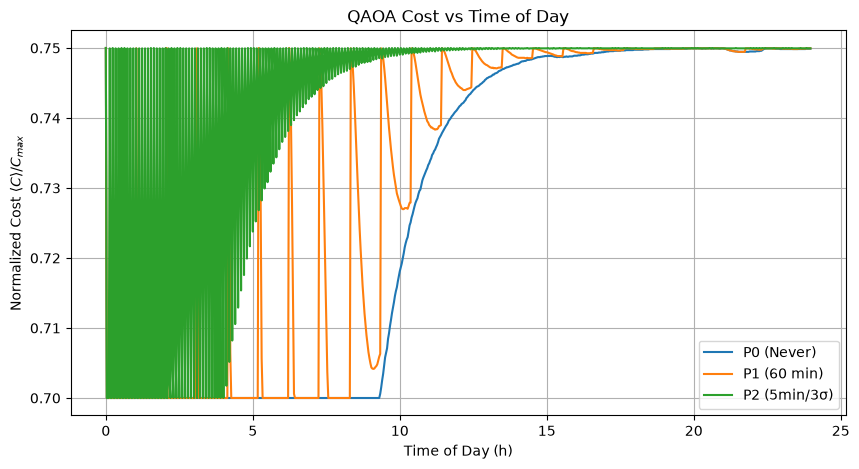

In [2]:
from q_autopilot_backend.sim.policy import simulate_day
from q_autopilot_backend.api.schemas import PolicyId

res_p0 = simulate_day(PolicyId.P0, {}, seed=2026, compute_qaoa=True)
res_p1 = simulate_day(PolicyId.P1, {'period_min': 60}, seed=2026, compute_qaoa=True)
res_p2 = simulate_day(PolicyId.P2, {'check_interval_min': 5, 'trigger_threshold': 3.0}, seed=2026, compute_qaoa=True)

plt.figure(figsize=(10, 5))
plt.plot(res_p0.t_h, res_p0.qaoa_ratio, label='P0 (Never)')
plt.plot(res_p1.t_h, res_p1.qaoa_ratio, label='P1 (60 min)')
plt.plot(res_p2.t_h, res_p2.qaoa_ratio, label='P2 (5min/3σ)')
plt.xlabel('Time of Day (h)')
plt.ylabel(r'Normalized Cost $\langle C \rangle / C_{max}$')
plt.title('QAOA Cost vs Time of Day')
plt.legend()
plt.grid(True)
plt.show()
